### Importación de librerías


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
from tabulate import tabulate
from itertools import product

# Modelos de Machine Learning
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import xgboost as xgb

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Model Selection y Validación
from sklearn.model_selection import (
    train_test_split, cross_val_score, learning_curve, validation_curve
)

# Métricas
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

### Cargar datos

In [2]:
df_limpio = pd.read_csv('../data/stg/IA_PROPENSITY_TRAIN_1.csv', index_col=0) 
df_limpio.head()

,TIPO_CARROCERIA,COMBUSTIBLE,Potencia,TRANS,FORMA_PAGO,ESTADO_CIVIL,GENERO,OcupaciOn,PROVINCIA,Campanna1,...,Zona_Renta,REV_Garantia,Averia_grave,QUEJA_CAC,COSTE_VENTA,km_anno,Mas_1_coche,Revisiones,Edad_Cliente,Tiempo
PRODUCTO,,,,,,,,,,,,,,,,,,,,,
0,0,0,1,1,0,0,2,1,4,1,...,3,0,2,1,2892,0,0,2,18,0
0,0,0,1,1,0,0,1,1,47,0,...,3,1,4,0,1376,7187,0,2,53,0
0,0,0,1,1,3,0,2,1,30,0,...,2,0,4,0,1376,0,1,4,21,3
0,0,0,1,1,2,0,1,1,32,1,...,2,1,2,1,2015,7256,1,4,48,5
0,0,0,1,1,2,0,1,1,4,1,...,2,1,1,0,2015,11293,0,2,56,0


In [3]:
X = df_limpio.drop(columns=['Tiempo', 'Mas_1_coche']) 
y = df_limpio['Mas_1_coche']  # Objetivo

# Dividir los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Random Forest

,criterion,max_depth,min_samples_split,min_samples_leaf,n_estimators,accuracy,f1_score,recall,roc_auc,cv_recall
2,entropy,30,9,3,400,0.827501,0.834385,0.827501,0.921295,0.803227
0,entropy,30,9,3,300,0.827190,0.834083,0.827190,0.921116,0.802518
3,entropy,30,12,3,400,0.823566,0.830844,0.823566,0.921018,0.812361
1,entropy,30,12,3,300,0.823152,0.830426,0.823152,0.921117,0.812184


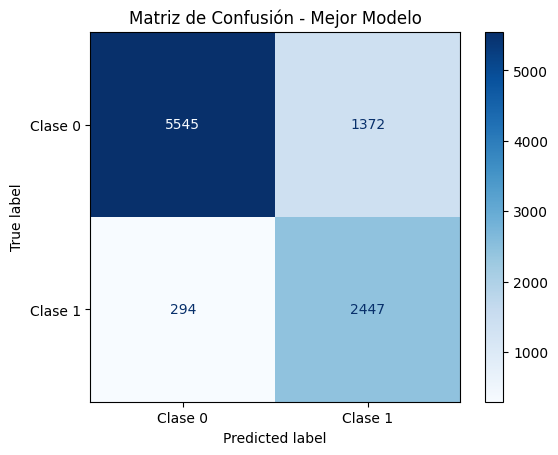

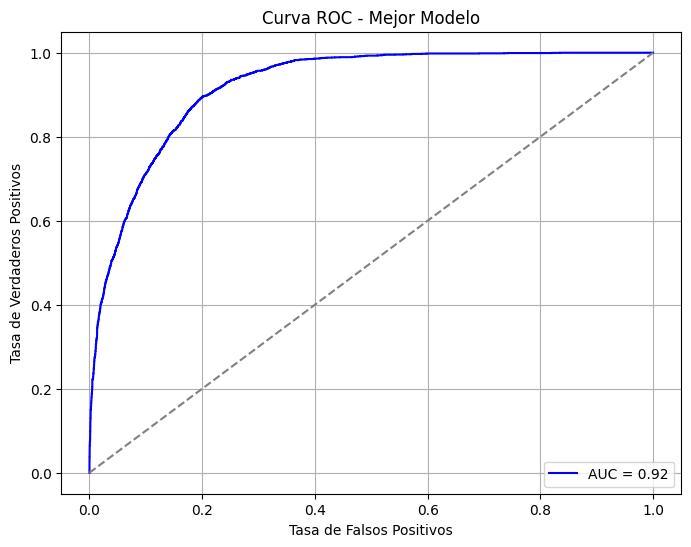

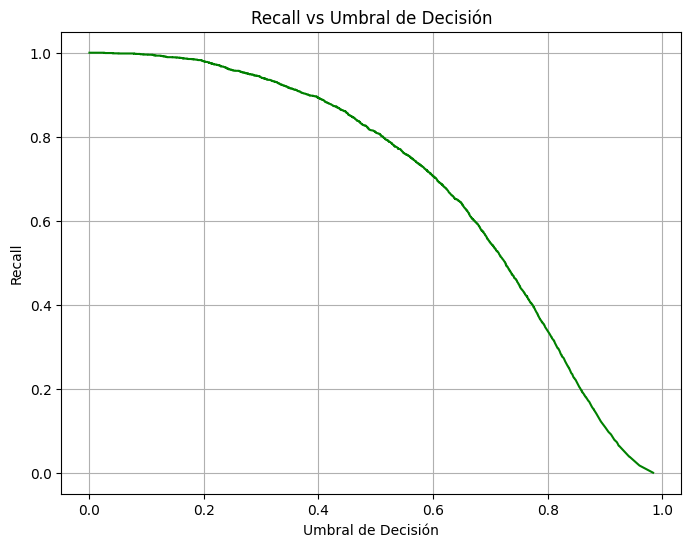

In [28]:
# Definir los parámetros de los modelos

param_grid = {
    'criterion': ['entropy'],
    'n_estimators': [300, 400],
    'max_depths' : [30],
    'min_samples_split': [9,12],
    'min_samples_leaf': [3]
}

# Almacenar los resultados

results = []

# Iterar sobre los parámetros

for params in product(*param_grid.values()):
    criterion, n_estimators, max_depth, min_samples_split, min_samples_leaf = params
    model = RandomForestClassifier(
        criterion=criterion,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight='balanced',
        random_state=42
    )

    # Entrenar el modelo

    model.fit(X_train, y_train)

    # Predecir el modelo en los datos de prueba

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.4).astype(int)

    # Calcular las métricas

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Validación cruzada

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')
    mean_cv_score = np.mean(cv_scores)
    
    # Guardar los resultados

    results.append({
        'criterion': criterion,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'n_estimators': n_estimators,
        'accuracy': accuracy,
        'f1_score': f1,
        'recall': recall,  # <-- Priorizar recall
        'roc_auc': roc_auc,
        'cv_recall': mean_cv_score  # <-- Guardar recall en validación cruzada
    })


# Convertir los resultados en un DataFrame

results_df = pd.DataFrame(results).sort_values(by=['recall', 'f1_score'], ascending=False)

# Mostrar los resultados

display(results_df.head(5))

# Seleccionar el mejor modelo

best_model_params = results_df.iloc[0]
best_model = RandomForestClassifier(
    criterion=best_model_params['criterion'],
    n_estimators=best_model_params['n_estimators'],
    max_depth=best_model_params['max_depth'],
    min_samples_split=best_model_params['min_samples_split'],
    min_samples_leaf=best_model_params['min_samples_leaf'],
    class_weight='balanced',
    random_state=42
)

# Entrenar el mejor modelo

best_model.fit(X_train, y_train)

# Predecir el modelo en los datos de prueba

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.4).astype(int)


# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión - Mejor Modelo')
plt.show()

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Graficar la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title(f'Curva ROC - Mejor Modelo')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Graficar Recall vs Umbral de decisión
plt.figure(figsize=(8, 6))
plt.plot(thresholds, tpr, label='Recall', color='green')
plt.title('Recall vs Umbral de Decisión')
plt.xlabel('Umbral de Decisión')
plt.ylabel('Recall')
plt.grid(True)
plt.show()

### XGBoost

In [4]:
# Definir los hiperparámetros
param_grid = {
    'learning_rate': [0.05, 0.1, 0.15],  # Reducir la tasa de aprendizaje
    'n_estimators': [500],  # Mantener el número de estimadores
    'max_depth': [6, 8, 10],  # Ajustar la profundidad de los árboles
    'min_child_weight': [4],  # Establecer el peso mínimo para el hijo
    'subsample': [0.75],  # Usar una fracción de las muestras para cada árbol
    'colsample_bytree': [0.8],  # Ajustar el número de características
    'gamma': [0.5],  # Mantener gamma bajo
    'reg_alpha': [5],  # Ajustar el valor de regularización L1
    'reg_lambda': [2],  # Ajustar el valor de regularización L2
    'scale_pos_weight': [1],  # Ajustar el balance de clases
    'base_score': [0.5],  # Mantener base_score en 0.5
}

In [5]:
# Almacenar los resultados
results = []

# Iterar sobre los parámetros
for params in product(*param_grid.values()):
    learning_rate, n_estimators, max_depth, min_child_weight, subsample, colsample_bytree, gamma, reg_alpha, reg_lambda, scale_pos_weight, base_score = params
    
    # Construir el modelo XGBoost
    model = XGBClassifier(
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        scale_pos_weight=scale_pos_weight,
        base_score=base_score,
        random_state=42
    )

    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Predecir
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.4).astype(int)

    # Calcular las métricas
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Validación cruzada
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_cv_score = np.mean(cv_scores)

    # Guardar los resultados
    results.append({
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_child_weight': min_child_weight,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'gamma': gamma,
        'reg_alpha': reg_alpha,
        'reg_lambda': reg_lambda,
        'scale_pos_weight': scale_pos_weight,
        'base_score': base_score,
        'accuracy': accuracy,
        'f1_score': f1,
        'recall': recall,
        'roc_auc': roc_auc,
        'cv_recall': mean_cv_score
    })

# Convertir los resultados a un DataFrame
results_df = pd.DataFrame(results).sort_values(by=['recall', 'f1_score'], ascending=False)

# Mostrar los resultados
display(results_df.head(5))

,learning_rate,n_estimators,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,scale_pos_weight,base_score,accuracy,f1_score,recall,roc_auc,cv_recall
7,0.15,500,8,4,0.75,0.8,0.5,5,2,1,0.5,0.858356,0.860816,0.858356,0.935490,0.855423
5,0.10,500,10,4,0.75,0.8,0.5,5,2,1,0.5,0.857735,0.860325,0.857735,0.936214,0.856873
8,0.15,500,10,4,0.75,0.8,0.5,5,2,1,0.5,0.857631,0.859902,0.857631,0.935747,0.856019
4,0.10,500,8,4,0.75,0.8,0.5,5,2,1,0.5,0.856492,0.858972,0.856492,0.935628,0.856769
3,0.10,500,6,4,0.75,0.8,0.5,5,2,1,0.5,0.855974,0.858554,0.855974,0.935936,0.856692


In [14]:
!pip install joblib

In [16]:
import joblib

# Guardar el modelo en un archivo pkl
joblib.dump(best_model, 'hiper_xgboost.pkl')


['hiper_xgboost.pkl']

In [6]:
results_df.to_csv('../models/hiper_xgboost.csv')

In [7]:
best_model_params = results_df.iloc[0]

In [8]:
best_model = XGBClassifier(
    learning_rate=best_model_params['learning_rate'],
    n_estimators=int(best_model_params['n_estimators']),
    max_depth=int(best_model_params['max_depth']),
    min_child_weight=int(best_model_params['min_child_weight']),
    subsample=best_model_params['subsample'],
    colsample_bytree=best_model_params['colsample_bytree'],
    gamma=best_model_params['gamma'],
    reg_alpha=best_model_params['reg_alpha'],
    reg_lambda=best_model_params['reg_lambda'],
    scale_pos_weight=best_model_params['scale_pos_weight'],
    base_score=best_model_params['base_score'],
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Entrenar el mejor modelo
best_model.fit(X_train, y_train)

XGBClassifier(base_score=np.float64(0.5), booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.8), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, gamma=np.float64(0.5),
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=np.float64(0.15),
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

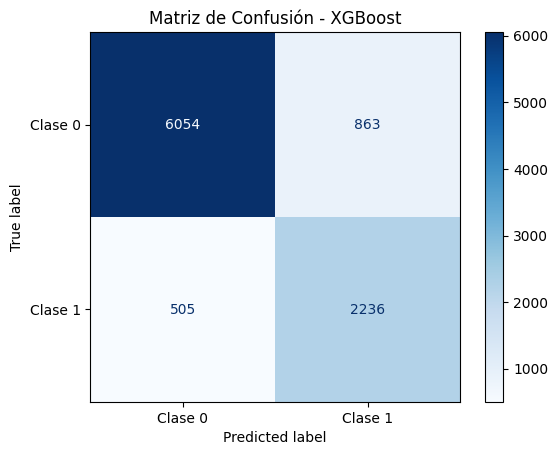

In [9]:
# Predecir el modelo en los datos de prueba
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.4).astype(int)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión - XGBoost')
plt.show()

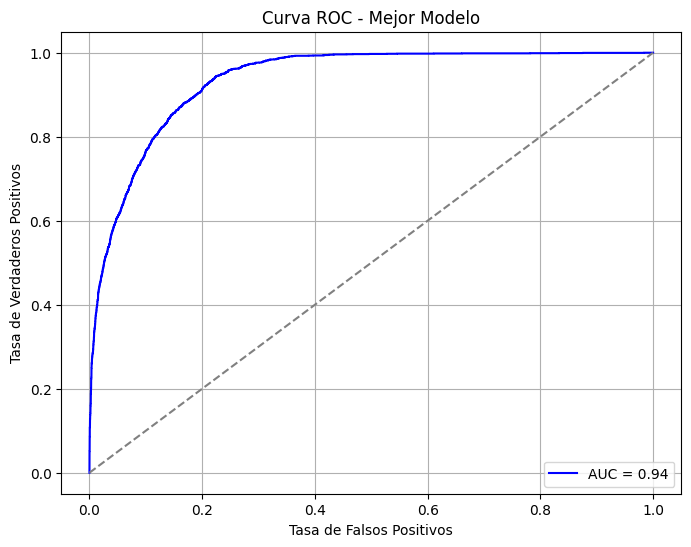

In [10]:
# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Graficar la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title(f'Curva ROC - Mejor Modelo')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

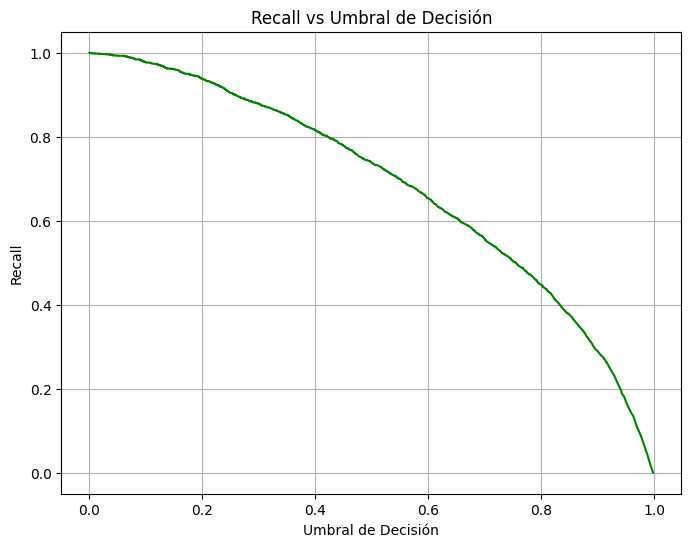

In [11]:
# Graficar Recall vs Umbral de decisión
plt.figure(figsize=(8, 6))
plt.plot(thresholds, tpr, label='Recall', color='green')
plt.title('Recall vs Umbral de Decisión')
plt.xlabel('Umbral de Decisión')
plt.ylabel('Recall')
plt.grid(True)
plt.show()

In [12]:
# Validación cruzada.
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
mean_cv_score = np.mean(cv_scores)

# Calculo Train Score.
train_score = best_model.score(X_train, y_train)

# Determinar si hay sobreajuste.
if train_score > 1.5 * mean_cv_score:
    overfitting_warning = "SEVERE OVERFITTING"
elif train_score > 1.2 * mean_cv_score:
    overfitting_warning = "DANGER"
elif train_score > 1.1 * mean_cv_score:
    overfitting_warning = "MILD OVERFITTING"
else:
    overfitting_warning = "OK"

print(f'Validación Cruzada para Confirmación de Generalización: {overfitting_warning}')

Validación Cruzada para Confirmación de Generalización: OK


In [13]:
train_recall = recall_score(y_train, best_model.predict(X_train))
test_recall = recall_score(y_test, best_model.predict(X_test))

recall_ratio = train_recall / test_recall
print(f"Train Recall: {train_recall:.3f}")
print(f"Test Recall: {test_recall:.3f}")
print(f"Recall Ratio: {recall_ratio:.2f}")

if recall_ratio < 1.15:
    print("El modelo mantiene un buen equilibrio en Recall entre Train y Test.")
else:
    print("Posible sobreajuste en Recall.")

Train Recall: 0.862
Test Recall: 0.738
Recall Ratio: 1.17
Posible sobreajuste en Recall.


<Figure size 1000x800 with 0 Axes>

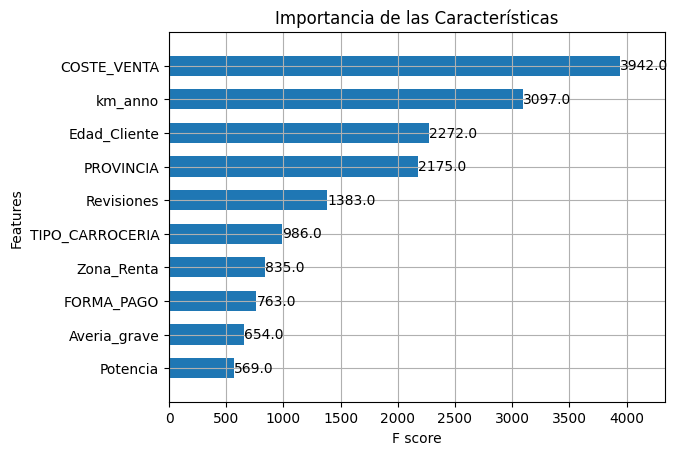

In [18]:
from xgboost import plot_importance

# Graficar la importancia de las características
plt.figure(figsize=(10, 8))
plot_importance(best_model, importance_type="weight", max_num_features=10, height=0.6, title="Importancia de las Características")
plt.show()

In [25]:
# Creación de la segmentación en base a la probabilidad de compra.
def segmentar_cliente(prob):
    if prob > 0.8:
        return "Alta Propensión"
    elif 0.8 >= prob > 0.5:
        return "Propensión Moderada"
    else:
        return "Baja Propensión"

# Crear una nueva columna de Probabilidad de Compra
df_resultados = X_test.copy()  # Crear una copia del dataset de prueba.
df_resultados["Probabilidad_Compra"] = best_model.predict_proba(X_test)[:, 1]
df_resultados["Segmento"] = df_resultados["Probabilidad_Compra"].apply(segmentar_cliente)

df_resultados.head()

,TIPO_CARROCERIA,COMBUSTIBLE,Potencia,TRANS,FORMA_PAGO,ESTADO_CIVIL,GENERO,OcupaciOn,PROVINCIA,Campanna1,...,Zona_Renta,REV_Garantia,Averia_grave,QUEJA_CAC,COSTE_VENTA,km_anno,Revisiones,Edad_Cliente,Probabilidad_Compra,Segmento
PRODUCTO,,,,,,,,,,,,,,,,,,,,,
2,3,1,2,1,0,4,2,1,4,0,...,0,0,1,0,1800,9101,2,47,0.631631,Propensión Moderada
0,0,0,1,1,0,4,2,1,28,0,...,3,0,4,0,3380,0,2,21,0.004743,Baja Propensión
8,6,0,0,1,3,0,2,1,0,0,...,2,1,4,0,1829,7259,2,56,0.003683,Baja Propensión
1,0,1,2,1,3,4,2,1,11,0,...,3,1,2,1,2616,23293,9,51,0.025967,Baja Propensión
1,5,1,2,1,0,0,1,1,4,0,...,0,0,0,0,3432,16827,4,51,0.437645,Baja Propensión


In [30]:
# Aplicación del umbral para la predicción.
umbral = 0.48

# Crear una nueva columna de Predicción
df_resultados["Prediccion_Modelo"] = (df_resultados["Probabilidad_Compra"] >= umbral).astype(int)

In [31]:
# Contar la cantidad de clientes en cada segmento
conteo_clientes = df_resultados["Segmento"].value_counts()

# Contar la cantidad de clientes que han comprado en cada segmento
compras_por_segmento = df_resultados[df_resultados["Prediccion_Modelo"] == 1]["Segmento"].value_counts()

# Calcular la tasa de conversión por segmento
tasa_conversion = (compras_por_segmento / conteo_clientes) * 100

# Crear un DataFrame con los resultados
df_tasa_conversion = pd.DataFrame({
    "Total Clientes": conteo_clientes,
    "Clientes que compraron": compras_por_segmento,
    "Tasa de Conversión (%)": tasa_conversion
}).fillna(0)  # Rellenar valores NaN con 0

df_tasa_conversion

,Total Clientes,Clientes que compraron,Tasa de Conversión (%)
Segmento,,,
Alta Propensión,1354,1354,100.000000
Baja Propensión,7008,77,1.098744
Propensión Moderada,1296,1296,100.000000


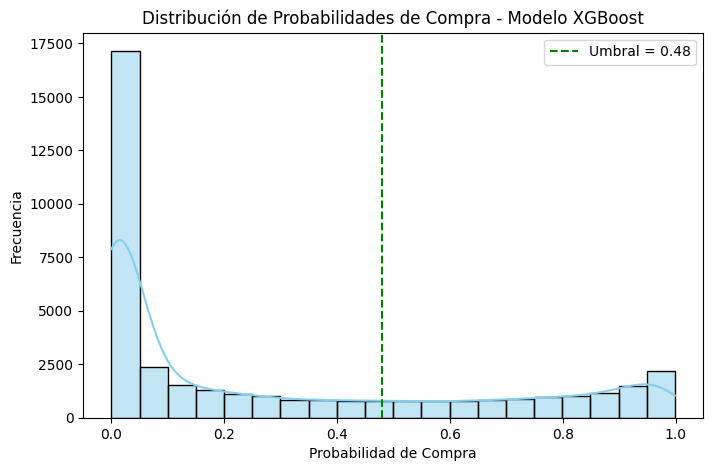

In [33]:
plt.figure(figsize=(8, 5))
sns.histplot(y_pred_proba, bins=20, color="skyblue", kde=True)
plt.axvline(x=umbral, color="green", linestyle="--", label=f"Umbral = {umbral}")
plt.xlabel("Probabilidad de Compra")
plt.ylabel("Frecuencia")
plt.title("Distribución de Probabilidades de Compra - Modelo XGBoost")
plt.legend()
plt.show()

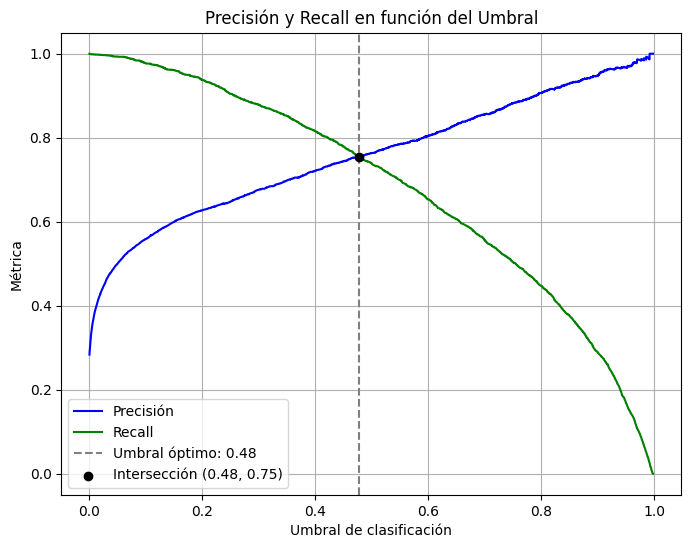

In [ ]:
y_scores = best_model.predict_proba(X_test)[:, 1]

# Calcular precision, recall y umbrales.
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Encontrar el punto de intersección entre precisión y recall.
diff = np.abs(precision - recall)
min_diff_idx = np.argmin(diff)
optimal_threshold = thresholds[min_diff_idx]
optimal_value = precision[min_diff_idx]

# Graficar Precision-Recall vs Umbral.
plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label="Precisión", color='blue')
plt.plot(thresholds, recall[:-1], label="Recall", color='green')
plt.axvline(x=optimal_threshold, linestyle="--", color="gray", label=f"Umbral óptimo: {optimal_threshold:.2f}")
plt.scatter(optimal_threshold, optimal_value, color="black", label=f"Intersección ({optimal_threshold:.2f}, {optimal_value:.2f})", zorder = 5)
plt.xlabel("Umbral de clasificación")
plt.ylabel("Métrica")
plt.grid(True)
plt.legend()
plt.title("Precisión y Recall en función del Umbral")
plt.show()


### AdaBoost

,n_estimators,learning_rate,estimator_depth,accuracy,f1_score,recall,roc_auc,cv_score,train_score,overfitting
1,500,0.68,7,0.859702,0.858213,0.859702,0.934132,0.856226,0.908827,OK
0,500,0.67,7,0.855871,0.854843,0.855871,0.934194,0.855035,0.909397,OK
2,500,0.69,7,0.854628,0.853416,0.854628,0.931528,0.854362,0.895289,OK


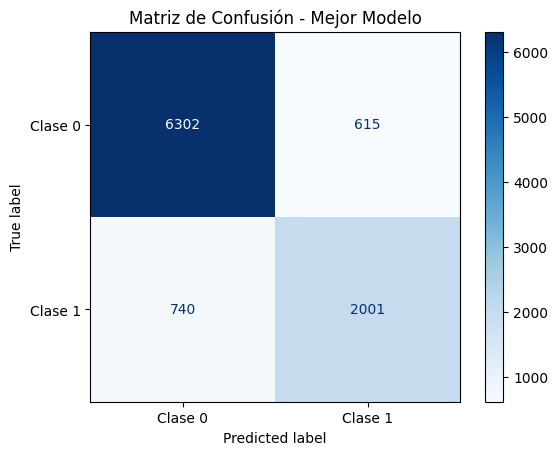

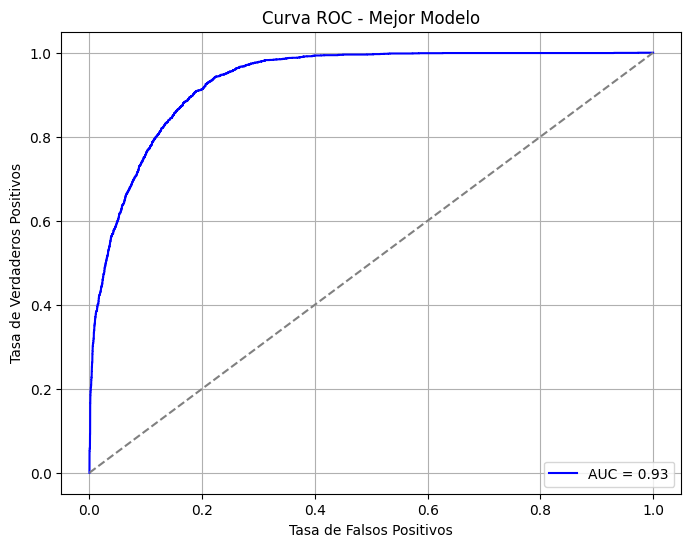

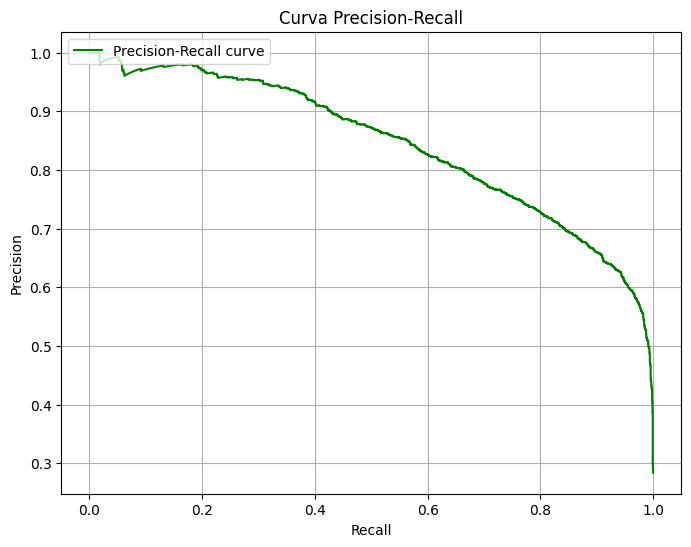

In [21]:
# Definir hiperparámetros a iterar
param_grid = {
    'n_estimators': [500],
    'learning_rate': [0.67, 0.68, 0.69],
    'estimator': [DecisionTreeClassifier(max_depth=7)]
}

# Almacenar resultados
results = []

# Iterar sobre todas las combinaciones de hiperparámetros
for params in product(*param_grid.values()):
    (n_estimators, learning_rate, estimator) = params
    
    # Construir el modelo
    model = AdaBoostClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        estimator=estimator,  # <--- Cambio aquí
        random_state=38
    )
    
    # Entrenar el modelo
    model.fit(X_train, y_train)
    
    # Predecir
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba) if len(np.unique(y_test)) > 1 else None
    
    # Validación cruzada
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_cv_score = np.mean(cv_scores)
    
    # Train Score
    train_score = model.score(X_train, y_train)
    
    # Evaluar sobreajuste
    if train_score > 1.5 * mean_cv_score:
        overfitting_warning = "SEVERE OVERFITTING"
    elif train_score > 1.2 * mean_cv_score:
        overfitting_warning = "DANGER"
    elif train_score > 1.1 * mean_cv_score:
        overfitting_warning = "MILD OVERFITTING"
    else:
        overfitting_warning = "OK"
    
    # Guardar resultados
    results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'estimator_depth': estimator.max_depth,
        'accuracy': accuracy,
        'f1_score': f1,
        'recall': recall,
        'roc_auc': roc_auc,
        'cv_score': mean_cv_score,
        'train_score': train_score,
        'overfitting': overfitting_warning
    })

# Convertir resultados a DataFrame y seleccionar los mejores modelos
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['f1_score', 'accuracy'], ascending=False)

# Seleccionar los mejores modelos sin sobreajuste
best_models = results_df[results_df['overfitting'] == 'OK'].head(3)

display(best_models)

# Entrenar el mejor modelo y visualizar métricas
best_model_params = best_models.iloc[0].to_dict()
best_model = AdaBoostClassifier(
    n_estimators=best_model_params['n_estimators'],
    learning_rate=best_model_params['learning_rate'],
    estimator=DecisionTreeClassifier(max_depth=best_model_params['estimator_depth']),  # <--- Cambio aquí
    random_state=42
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión - Mejor Modelo')
plt.show()

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Graficar la Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title(f'Curva ROC - Mejor Modelo')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Graficar la Curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', label='Precision-Recall curve')
plt.title('Curva Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


### Gradient Boosting

In [4]:
# Definir los parámetros de Gradient Boosting

param_grid = {
    'n_estimators': [300],  # Número de estimadores (árboles)
    'subsample': [1.0],  # Fracción de muestras usadas en cada árbol (submuestreo)
    'criterion': ['friedman_mse'],  # Criterio de división (friedman_mse y squared_error son comunes)
    'min_samples_split': [8,10],  # Mínimo número de muestras necesarias para dividir un nodo
    'min_samples_leaf': [10],  # Mínimo número de muestras requeridas en una hoja
    'max_depth': [3,10],  # Profundidad máxima de los árboles
   }

# Almacenar los resultados
results = []

# Iterar sobre los parámetros
for params in product(*param_grid.values()):
    n_estimators, subsample, criterion, min_samples_split, min_samples_leaf, max_depth= params
    
    # Crear el modelo Gradient Boosting con los parámetros proporcionados
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        criterion=criterion,
        random_state=42
    )

    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Predecir el modelo en los datos de prueba
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.4).astype(int)  # Ajustar el umbral de decisión

    # Calcular las métricas
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    
    # Calcular ROC-AUC si hay más de una clase
    if len(np.unique(y_test)) > 1:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None

    # Validación cruzada
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')
    mean_cv_score = np.mean(cv_scores)
    
    # Calcular Train Score
    train_score = model.score(X_train, y_train)
    
    # Determinar si hay sobreajuste
    if train_score > 1.5 * mean_cv_score:
        overfitting_warning = "SEVERE OVERFITTING"
    elif train_score > 1.2 * mean_cv_score:
        overfitting_warning = "DANGER"
    elif train_score > 1.1 * mean_cv_score:
        overfitting_warning = "MILD OVERFITTING"
    else:
        overfitting_warning = "OK"

    # Guardar los resultados
    results.append({
        'criterion': criterion,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'n_estimators': n_estimators,
        'accuracy': accuracy,
        'f1_score': f1,
        'recall': recall,
        'roc_auc': roc_auc,
        'cv_score': mean_cv_score,
        'train_score': train_score,
        'overfitting': overfitting_warning
    })

# Convertir los resultados en un DataFrame y ordenar
results_df = pd.DataFrame(results).sort_values(by=['accuracy', 'f1_score'], ascending=False)

# Seleccionar el mejor modelo sin sobreajuste y optimizando F1 Score
best_models = results_df[results_df['overfitting'] == 'OK'].head(3)

# Mostrar los mejores resultados
from IPython.display import display
display(best_models)

# Matriz de confusión y Curvas ROC/Precision-Recall del mejor modelo
if not best_models.empty:
    best_model_params = best_models.iloc[0].to_dict()
    best_model = GradientBoostingClassifier(
        n_estimators=best_model_params["n_estimators"],
        max_depth=best_model_params["max_depth"],
        min_samples_split=best_model_params["min_samples_split"],
        min_samples_leaf=best_model_params["min_samples_leaf"],
        criterion=best_model_params["criterion"],
        random_state=42
    )
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    # Matriz de Confusión
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Matriz de Confusión - {best_model_params["criterion"]}')
    plt.show()

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC={roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC - {best_model_params["criterion"]}')
    plt.legend()
    plt.show()

    # Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    plt.figure()
    plt.plot(recall, precision, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Curva Precision-Recall - {best_model_params["criterion"]}')
    plt.legend()
    plt.show()
else:
    print("No suitable model found without overfitting.")

,criterion,max_depth,min_samples_split,min_samples_leaf,n_estimators,accuracy,f1_score,recall,roc_auc,cv_score,train_score,overfitting


No suitable model found without overfitting.
